# Transaction volume evolve XRP (Ripple)

How does XRP transaction volume evolve over times?
Answering that question help us to understand what it's happening on the cripto word. XRP is in the top ten famous and usefull cripocurrency because of that, we can have a general overview on what's going on in the near future.

## Dataset
This dataset contains historical XRPUSD price and volume data from Binance. The data is provided in 1-minute intervals and includes standard OHLCV (Open, High, Low, Close, Volume) metrics, along with additional details such as the number of trades and taker volumes when available.

**Open time** -- The timestamp, in UTC date format, when the candlestick (price bar) open.

**Open** -- The price of the asset at the beginning of the trading period.

**Hight** -- The highest price of the asset during the trading period.

**Low** -- The lowest price of the asset during the trading period.

**Close** -- The price of the asset at the end of the trading period.

**Volume** -- The total volume of the asset traded during the period.

**Close time** -- The timestamp, in UTC date format, when the candlestick (price bar) close.

**Quote asset volume** -- The total trading volume in the quote asset (e.g., USDT) during the period.

**Number of trades** -- The number of trades executed during the period.

**Taker buy base asset volume** -- The total amount of the base asset (e.g., BTC) bought by takers during the period.

**Taker buy quote asset volume** -- The total amount of the quote asset (e.g., BTC) bought by takers during the period.

## Steps
**1. EDA Analyst**
Explore and clean the data

**2. Create a bar chart**
Create a bar plot to visualize the information

**3. Conclusions**

In [ ]:
# Import libraries 
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
xrp = pd.read_csv('Dataset/XRP.csv')
xrp.head()

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2018-05-04 08:11:00,0.50000,0.50000,0.50000,0.50000,109.51,2018-05-04 08:11:59.999,54.755000,1.0,0.00,0.000000,0.0
1,2018-05-04 08:12:00,0.90000,0.92999,0.85000,0.90000,167543.47,2018-05-04 08:12:59.999,150546.372022,147.0,129949.27,116854.604432,0.0
2,2018-05-04 08:13:00,0.90000,0.93000,0.89001,0.91000,179750.59,2018-05-04 08:13:59.999,162900.065968,153.0,109352.28,99399.429752,0.0
3,2018-05-04 08:14:00,0.91000,1.50000,0.90009,0.92999,107222.48,2018-05-04 08:14:59.999,102862.811824,209.0,58084.74,57344.325309,0.0
4,2018-05-04 08:15:00,0.92999,0.95001,0.91020,0.91020,171304.56,2018-05-04 08:15:59.999,157893.851421,535.0,28832.40,26792.207204,0.0


In [10]:
xrp.info()

<class 'pandas.DataFrame'>
RangeIndex: 3906756 entries, 0 to 3906755
Data columns (total 12 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   Open time                     str    
 1   Open                          float64
 2   High                          float64
 3   Low                           float64
 4   Close                         float64
 5   Volume                        float64
 6   Close time                    str    
 7   Quote asset volume            float64
 8   Number of trades              float64
 9   Taker buy base asset volume   float64
 10  Taker buy quote asset volume  float64
 11  Ignore                        float64
dtypes: float64(10), str(2)
memory usage: 357.7 MB


In [11]:
print(xrp.describe())

               Open          High           Low         Close        Volume  \
count  3.906756e+06  3.906756e+06  3.906756e+06  3.906756e+06  3.906756e+06   
mean   7.392586e-01  7.398465e-01  7.386614e-01  7.392624e-01  2.456392e+05   
std    7.145818e-01  7.151386e-01  7.140194e-01  7.145811e-01  5.699730e+05   
min    1.057300e-01  1.068400e-01  1.012900e-01  1.058900e-01  0.000000e+00   
25%    3.245000e-01  3.247000e-01  3.242600e-01  3.245000e-01  3.720470e+04   
50%    4.931000e-01  4.935000e-01  4.927800e-01  4.931000e-01  1.032000e+05   
75%    7.101000e-01  7.106050e-01  7.096000e-01  7.101000e-01  2.499340e+05   
max    3.653700e+00  3.660700e+00  3.650000e+00  3.653700e+00  6.366178e+07   

       Quote asset volume  Number of trades  Taker buy base asset volume  \
count        3.906756e+06      3.906756e+06                 3.906756e+06   
mean         1.923331e+05      3.538033e+02                 1.218586e+05   
std          5.438706e+05      9.335226e+02                 

## 1. EDA analyst

Let's clean the titles, put it in minus and snake case, erase the column "Ignore", then convert the columns "Open time" and "Close time" to a datatime.

In [12]:
# Clean titles
xrp.columns = xrp.columns.str.lower().str.replace(" ","_")

# Change columns to datetime
xrp['open_time'] = pd.to_datetime(xrp['open_time'], format= '%Y-%m-%d %H:%M:%S')
xrp['close_time'] = pd.to_datetime(xrp['close_time'], format='mixed')

# Erase 'ignore' column
xrp = xrp.drop('ignore', axis= 1)

# Verify the changes
print(xrp.info('deep'), display(xrp.head()))

<class 'pandas.DataFrame'>
RangeIndex: 3906756 entries, 0 to 3906755
Data columns (total 11 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   open_time                     datetime64[us]
 1   open                          float64       
 2   high                          float64       
 3   low                           float64       
 4   close                         float64       
 5   volume                        float64       
 6   close_time                    datetime64[us]
 7   quote_asset_volume            float64       
 8   number_of_trades              float64       
 9   taker_buy_base_asset_volume   float64       
 10  taker_buy_quote_asset_volume  float64       
dtypes: datetime64[us](2), float64(9)
memory usage: 327.9 MB


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
0,2018-05-04 08:11:00,0.50000,0.50000,0.50000,0.50000,109.51,2018-05-04 08:11:59.999,54.755000,1.0,0.00,0.000000
1,2018-05-04 08:12:00,0.90000,0.92999,0.85000,0.90000,167543.47,2018-05-04 08:12:59.999,150546.372022,147.0,129949.27,116854.604432
2,2018-05-04 08:13:00,0.90000,0.93000,0.89001,0.91000,179750.59,2018-05-04 08:13:59.999,162900.065968,153.0,109352.28,99399.429752
3,2018-05-04 08:14:00,0.91000,1.50000,0.90009,0.92999,107222.48,2018-05-04 08:14:59.999,102862.811824,209.0,58084.74,57344.325309
4,2018-05-04 08:15:00,0.92999,0.95001,0.91020,0.91020,171304.56,2018-05-04 08:15:59.999,157893.851421,535.0,28832.40,26792.207204


None None


In [19]:
# To separate date
xrp['year'] = xrp['open_time'].dt.isocalendar().year
xrp['month'] = xrp['open_time'].dt.month
xrp['session_week'] = xrp['open_time'].dt.isocalendar().week
xrp['session_date'] = xrp['open_time'].dt.date

In [20]:
print(xrp.info('deep'), display(xrp.head()))

<class 'pandas.DataFrame'>
RangeIndex: 3906756 entries, 0 to 3906755
Data columns (total 15 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   open_time                     datetime64[us]
 1   open                          float64       
 2   high                          float64       
 3   low                           float64       
 4   close                         float64       
 5   volume                        float64       
 6   close_time                    datetime64[us]
 7   quote_asset_volume            float64       
 8   number_of_trades              float64       
 9   taker_buy_base_asset_volume   float64       
 10  taker_buy_quote_asset_volume  float64       
 11  year                          UInt32        
 12  month                         int32         
 13  session_week                  UInt32        
 14  session_date                  object        
dtypes: UInt32(2), datetime64[us](2), float64(9)

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,year,month,session_week,session_date
0,2018-05-04 08:11:00,0.50000,0.50000,0.50000,0.50000,109.51,2018-05-04 08:11:59.999,54.755000,1.0,0.00,0.000000,2018,5,18,2018-05-04
1,2018-05-04 08:12:00,0.90000,0.92999,0.85000,0.90000,167543.47,2018-05-04 08:12:59.999,150546.372022,147.0,129949.27,116854.604432,2018,5,18,2018-05-04
2,2018-05-04 08:13:00,0.90000,0.93000,0.89001,0.91000,179750.59,2018-05-04 08:13:59.999,162900.065968,153.0,109352.28,99399.429752,2018,5,18,2018-05-04
3,2018-05-04 08:14:00,0.91000,1.50000,0.90009,0.92999,107222.48,2018-05-04 08:14:59.999,102862.811824,209.0,58084.74,57344.325309,2018,5,18,2018-05-04
4,2018-05-04 08:15:00,0.92999,0.95001,0.91020,0.91020,171304.56,2018-05-04 08:15:59.999,157893.851421,535.0,28832.40,26792.207204,2018,5,18,2018-05-04


None None


## 2. Create a bar chart

I will merge the columns "open_time" with "quote_asset_volume" using 'group by'

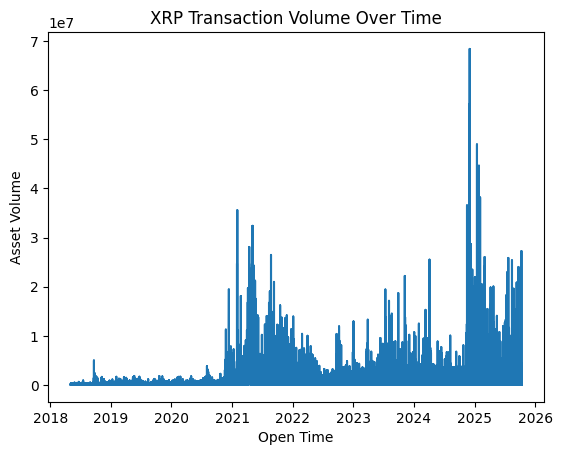

In [22]:
plt.figure()
plt.plot(xrp['session_date'], xrp['quote_asset_volume'])
plt.title('XRP Transaction Volume Over Time')
plt.xlabel('Open Time')
plt.ylabel('Asset Volume')
plt.show()

In [ ]:
# Hight transactions volume
xrp.loc[xrp['quote_asset_volume'].idxmax(), ['session_date', 'quote_asset_volume']]

session_date               2024-12-02
quote_asset_volume    68398157.907947
Name: 3456242, dtype: object

## 3. Conclusion

As we can see in the chart, XRP has been years when the volume is for far more than others, staring 2021 reach almost the 4e7 just one year after the pandemic. the highest in the history asset volume was in 2024-12-02 with a quote of 68398157.907947.
We can say it has a lot of volatility. Can be a good asset for a professional traders.